# Dynamic Pricing of Parking Spaces
Demonstrating the impact of additional consumers on the optimal prices of parking spaces.

In [31]:
import random
import ipywidgets as widgets
from ipywidgets import interact
import matplotlib.pyplot as plt

# Set the seed for reproducibility
random.seed(42)

In [32]:
def simulate_macro_demand():
    # Simulate demand for n items
    demand = [random.randint(1, 100) for _ in range(30)]

    # Divide the demand by 10 to get a value between 0.1 and 10
    demand = [round(d / 10, 1) for d in demand]

    # Sort the demand, with the highest demand first
    return demand

def simulate_demand(n=20, simple=False, simple_demand=None):
    """
    Simulate the demand function of a number of customers.

    Parameters
    ----------
    n : int
        The number of customers to simulate demand for. Default is 20.
    
    simple : bool
        If True, the demand is not newly calculated for each customer.

    Returns
    -------
    list
        A list of integers representing the willingness-to-pay for each customer.
        Each integer is a random number between 0.1 and 10.
    """
    # If simple is True, use the provided simple_demand list
    if simple:
        # Return n pseudo random elements of the simple_demand list
        demand = random.sample(simple_demand, n)
        return simple_demand[:n]

    # Simulate demand for n items
    demand = [random.randint(1, 100) for _ in range(n)]

    # Divide the demand by 10 to get a value between 0.1 and 10
    demand = [round(d / 10, 1) for d in demand]

    # Sort the demand, with the highest demand first
    demand.sort(reverse=True)

    return demand

def get_quantity(demand, price, units_available=10):
    """
    Calculate the quantity demanded at a given price.

    Parameters
    ----------
    demand : list
        A list of integers representing the willingness-to-pay for each customer.
    price : float
        The price at which to calculate the quantity demanded.

    Returns
    -------
    int
        The quantity demanded at the given price.
    """
    quantity = sum(1 for d in demand if d >= price)
    return min(quantity, units_available)

def get_quantity_at_prices(demand):
    """
    Calculate the quantity demanded at a range of prices.

    Parameters
    ----------
    demand : list
        A list of integers representing the willingness-to-pay for each customer.

    Returns
    -------
    list
        A list of integers representing the quantity demanded at each price.
    """
    prices = [round(i / 10, 1) for i in range(1, 101)]
    quantities = [sum(1 for d in demand if d >= p) for p in prices]
    return prices, quantities


In [ ]:
def calculate_profit(price, demand, available_units=10):
    """
    Calculate the profit for a given price and demand.

    Parameters
    ----------
    price : float
        The price at which the product is sold.
    demand : list
        A list of integers representing the willingness-to-pay for each customer.
    available_units : int
        The number of units available for sale. Default is 10.

    Returns
    -------
    float
        The profit made from selling the product at the given price.
    """
    # Calculate the number of customers willing to pay the price
    customers = sum(1 for d in demand if d >= price)

    # Calculate the number of units sold, limited by available units
    units_sold = min(customers, available_units)

    # Calculate profit
    profit = units_sold * (price) 

    return profit

def get_profit_maximising_price(demand, available_units=10):
    """
    Calculate the profit for a given price and demand.

    Parameters
    ----------
    demand : list
        A list of integers representing the willingness-to-pay for each customer.
    available_units : int
        The number of units available for sale. Default is 10.

    Returns
    -------
    float
        The profit-maximising price.
    """
    # Create a list of possible prices with values from 0.1 to 10
    # with a step of 0.1
    possible_prices = [round(i * 0.1, 1) for i in range(1, 101)]
    profit_maximising_price = 0.1
    max_profit = 0

    for price in possible_prices:
        # Calculate profit for the current price
        profit = calculate_profit(price, demand, available_units)

        # Update max profit and price if current profit is greater
        if profit > max_profit:
            max_profit = profit
            profit_maximising_price = price


    return profit_maximising_price

In [34]:
demand = simulate_demand()
profit_maximising_price = get_profit_maximising_price(demand)
quantity = get_quantity(demand, profit_maximising_price)
print(f"Profit-maximising price: {profit_maximising_price}")
print(f"Quantity sold at profit-maximising price: {quantity}")

Profit-maximising price: 3.2
Quantity sold at profit-maximising price: 10


### Dynamic Optimal Price
The demand and supply graph shows the optimal pricing per parking space, dynamically dependent on:

- The number of **potential customers** looking for a parking space.
- The number of **parking spaces** available on the parking lot (i.e. the total supply).



In [35]:
def graph_supply_demand_curve(prices, quantities, quantity_at_prices, profit_maximising_price, quantity, max_quantity):
    """
    Graph the supply and demand curve with switched axes (Quantity on x, Price on y).
    """

    # Plot the demand curve (switched axes)
    plt.step(quantities, prices, label='Demand Curve', color='black')


    # Plot the straight lines (switched axes)
    plt.axvline(x=max_quantity, color='#c0c0c0', linestyle='-', label='Max Quantity')
    plt.axvline(x=quantity, color='#46db75', linestyle='--', label='Quantity Sold')
    plt.axhline(y=profit_maximising_price, color='#198ebd', linestyle='--', label='Profit-Maximising Price')

    # Shade the "Revenue" rectangle (switched axes)
    plt.fill_between([0, quantity], 0, profit_maximising_price, color='#b2edda', alpha=0.5)

    # Add label to shaded area
    plt.text((quantity / 2) -1, profit_maximising_price / 2, 'Revenue', fontsize=10, color='black')

    # Add labels and title
    plt.xlabel('Demanded Quantity (of Parking Spaces)')
    plt.ylabel('Price (per Parking Space)')
    plt.title('Supply and Demand Curve', fontsize=10)

    # Add a white grid and background
    plt.grid(color='white', linestyle='-', linewidth=0.5)
    plt.gca().set_facecolor('#f4f4f4')

    # Create a legend
    plt.legend(loc='upper right')

    # Set axis limits
    plt.xlim(0, max(quantities))
    plt.ylim(0, max(prices))

    # Show the plot
    plt.show()


# Presimulate the simple demand
simple_demand = simulate_macro_demand()

@interact(n=widgets.IntSlider(value=30, min=5, max=30, step=1, description='Nr. of Potential Customers'),
          max_quantity=widgets.IntSlider(value=10, min=1, max=20, step=1, description='Nr. of Parking Spaces'))
def interactive_demand_simulation(n, max_quantity):
    demand = simulate_demand(n=n, simple=True, simple_demand=simple_demand)
    prices, quantities = get_quantity_at_prices(demand)
    profit_maximising_price = get_profit_maximising_price(demand, max_quantity)
    profit_maximising_quantity = get_quantity(demand, profit_maximising_price, max_quantity)
    
    graph_supply_demand_curve(prices, quantities, 
                              profit_maximising_price, 
                              profit_maximising_price, 
                              profit_maximising_quantity, 
                              max_quantity)

interactive(children=(IntSlider(value=30, description='Nr. of Potential Customers', max=30, min=5), IntSlider(…

### Impact of the Number of Potential Customers on the Optimal Price

The following graph illustrates the impact of more potential customers on the optimal price charged.

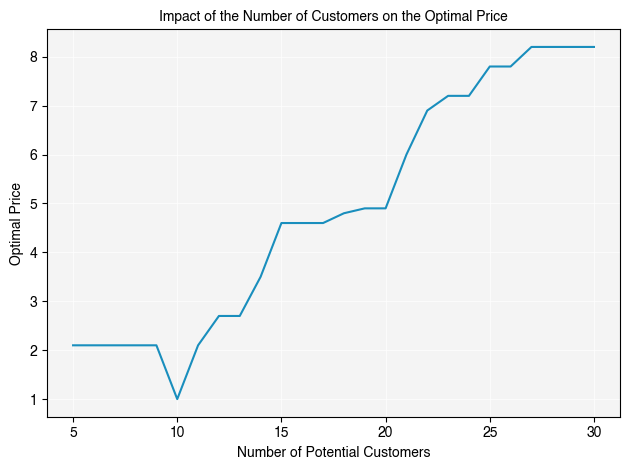

In [36]:
simple_demand = simulate_macro_demand()
max_quantity = 10
consumers = []
optimal_price = []
optimal_quantity = []

for n in range(5, 31):
    # Simulate demand for n items
    demand = simulate_demand(n=n, simple=True, simple_demand=simple_demand)
    prices, quantities = get_quantity_at_prices(demand)
    profit_maximising_price = get_profit_maximising_price(demand, max_quantity)
    profit_maximising_quantity = get_quantity(demand, profit_maximising_price, max_quantity)
    consumers.append(n)
    optimal_price.append(profit_maximising_price)
    optimal_quantity.append(profit_maximising_quantity)


def graph_optimal_price(consumers, optimal_price, optimal_quantity):
    """
    Graph the optimal price and quantity.

    Parameters
    ----------
    consumers : list
        A list of integers representing the number of consumers.
    optimal_price : list
        A list of floats representing the optimal price for each number of consumers.
    optimal_quantity : list
        A list of integers representing the optimal quantity for each number of consumers.
    """

    # Plot the optimal price on the first y-axis
    plt.plot(consumers, optimal_price, color='#198ebd', label='Optimal Price')
    plt.xlabel('Number of Potential Customers')
    plt.ylabel('Optimal Price', color='black')
    plt.tick_params(axis='y', labelcolor='black')

    # Add a title and grid
    plt.title('Impact of the Number of Customers on the Optimal Price', fontsize=10)
    plt.tight_layout()

    # Set a white grid and background
    plt.grid(color='white', linestyle='-', linewidth=0.5)
    plt.gca().set_facecolor('#f4f4f4')


    
    # Show the plot in dpi=300
    plt.savefig('optimal_price_vs_customers.png', dpi=300)
    plt.show()

graph_optimal_price(consumers, optimal_price, optimal_quantity)
